# 🛰️ 데이터 원천: MODIS (Terra/Aqua 위성)

NASA의 MODIS 센서는 전 지구 식생 모니터링의 글로벌 표준입니다.
- **공간 해상도** : 250m (온도는 1km)
- **시간 해상도** : 16일 주기(온도는 8일 주기) → 구름 제거 후 **월별 합성 (Monthly Composite)** 가공
- **업데이트 주기** : 실시간 (Near Real-Time; 약 2~3일 내외)
- **평년 기간** : 2003년 ~ 2022년 (20년; MODIS 데이터의 신뢰성이 높은 구간을 평년 기준으로 설정)

# 🌿 식생 지수(Vegetation Indices) 핵심 설명

## 1. NDVI & EVI (현재 상태의 푸르름)

가장 기초적인 지표로, 식물이 얼마나 싱싱한지를 나타냅니다.

* **NDVI (Normalized Difference Vegetation Index):** 식물의 엽록소가 반사하는 빛을 측정합니다. 1에 가까울수록 울창하고, 0에 가까우면 메마른 땅입니다.
$$NDVI = \frac{NIR - RED}{NIR + RED}$$

* **EVI (Enhanced Vegetation Index):** NDVI의 단점인 대기 노이즈와 빽빽한 숲에서의 수치 포화 현상을 보정한 지수입니다. 동아프리카의 우기(Rainy Season) 분석에 더 정밀한 값을 제공합니다.

## 2. VCI (Vegetation Condition Index, 식생 상태 지수)

과거 이맘때와 비교해서 얼마나 푸른가를 보여줍니다.

* **산출 방식:** 현재 NDVI가 과거 20년 동안의 최솟값(Min)과 최댓값(Max) 사이에서 어느 위치에 있는지 0~100으로 표현합니다.
* **해석:** **30 이하**면 과거 기록에 비추어 볼 때 심각한 식생 가뭄이 발생한 것으로 간주합니다.

## 3. VHI (Vegetation Health Index, 식생 건강 지수) - **최종 지표**

식생(VCI)과 온도(TCI) 스트레스를 5:5로 결합한 **종합 가뭄 지수**입니다.
$$VHI = 0.5 \times VCI + 0.5 \times TCI$$

* **특징:** 단순히 풀이 마른 것뿐만 아니라, 지면 온도(LST)가 비정상적으로 높아 식물이 열 스트레스를 받는 상황까지 반영합니다.
* **용도:** **가뭄으로 인한 작물 수확량 감소**를 예측할 때 가장 상관관계가 높은 '끝판왕' 변수입니다.

## GEE - Setting

In [1]:
import ee

# ⚠️ 중요: 아래에 사용 중인 Google Cloud Project ID를 입력해야 합니다.
# GEE Code Editor (https://code.earthengine.google.com/) 우측 상단 등에서 확인 가능합니다.
project_id = 'wfp-project-486106'

# GEE 인증 및 초기화
try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

In [2]:
# ==========================================
# 🚀 사용자 설정
# ==========================================
# 동아프리카 ROI (Region of Interest)
ROI = ee.Geometry.Rectangle([25, -15, 52, 22])

# 분석 기간 (2007 ~ 2025)
TARGET_START = '2007-01-01'
TARGET_END = '2025-12-31'

# 평년 기준 (Historical Baseline for VCI/TCI)
# MODIS 데이터가 안정적인 2003년부터 2022년까지를 평년으로 설정
REF_START = '2003-01-01'
REF_END = '2022-12-31'

EXPORT_DESC = 'EastAfrica_Vegetation_Indices'

# [중요] 해상도 설정 (단위: 미터)
# - 원본 NDVI는 250m이지만, LST(온도)가 1km입니다.
# - VHI 계산을 위해 1000m로 맞추는 것이 물리적으로 타당하며 용량 관리에도 좋습니다.
# 1km (1000) -> 5.5km (5566) 변경
# CHIRPS 강수량 데이터와 격자 크기를 맞추고, 용량을 1/25로 줄입니다.
RESOLUTION = 5566
# ==========================================

## GEE - Calculate & Export

In [ ]:
# 2. 데이터셋 로드 및 전처리 함수

# (1) MODIS NDVI/EVI (MOD13Q1: 16일 주기, 250m)
def load_ndvi(img):
    # Scale Factor: 0.0001
    return img.select(['NDVI', 'EVI']).multiply(0.0001).copyProperties(img, ['system:time_start'])

modis_vi = ee.ImageCollection("MODIS/061/MOD13Q1").map(load_ndvi)

# (2) MODIS LST (MOD11A2: 8일 주기, 1km)
def load_lst(img):
    # Scale Factor: 0.02, Kelvin -> Celsius 변환
    lst = img.select('LST_Day_1km').multiply(0.02).subtract(273.15).rename('LST')
    return lst.copyProperties(img, ['system:time_start'])

modis_lst = ee.ImageCollection("MODIS/061/MOD11A2").map(load_lst)

In [ ]:
# 3. 월별 합성 (Monthly Composite) 함수
# - NDVI/EVI: 구름 영향을 피하기 위해 최대값 합성 (Max Composite) 권장
# - LST: 평균값 합성 (Mean Composite)
def create_monthly_composite(start_date, end_date):
    n_months = ee.Date(end_date).difference(ee.Date(start_date), 'month').round()

    def make_monthly(n):
        date = ee.Date(start_date).advance(n, 'month')
        next_date = date.advance(1, 'month')

        # NDVI/EVI: Max Composite
        vi_mon = modis_vi.filterDate(date, next_date).max()

        # LST: Mean Composite
        lst_mon = modis_lst.filterDate(date, next_date).mean()

        # 병합
        return vi_mon.addBands(lst_mon).set('system:time_start', date.millis()).set('month', date.get('month'))

    return ee.ImageCollection(ee.List.sequence(0, n_months.subtract(1)).map(make_monthly))

In [ ]:
# 4. 평년값(Climatology Min/Max) 계산 (2003-2022)
# VCI, TCI 계산을 위해 월별 절대 최대/최소값이 필요합니다.

ref_col = create_monthly_composite(REF_START, REF_END)

monthly_stats = []
for m in range(1, 13):
    m_col = ref_col.filter(ee.Filter.eq('month', m))

    # NDVI Min/Max
    ndvi_min = m_col.select('NDVI').min().rename('NDVI_min')
    ndvi_max = m_col.select('NDVI').max().rename('NDVI_max')

    # LST Min/Max
    lst_min = m_col.select('LST').min().rename('LST_min')
    lst_max = m_col.select('LST').max().rename('LST_max')

    stats = ndvi_min.addBands(ndvi_max).addBands(lst_min).addBands(lst_max).set('month', m)
    monthly_stats.append(stats)

ee_monthly_stats = ee.List(monthly_stats)

In [ ]:
# 5. 타겟 기간 지수 산출 (VCI, TCI, VHI)
target_col = create_monthly_composite(TARGET_START, TARGET_END)

def calculate_indices(img):
    m = img.date().get('month')
    stats = ee.Image(ee_monthly_stats.get(m.subtract(1)))

    # 변수 추출
    ndvi = img.select('NDVI')
    lst = img.select('LST')

    ndvi_min = stats.select('NDVI_min')
    ndvi_max = stats.select('NDVI_max')
    lst_min = stats.select('LST_min')
    lst_max = stats.select('LST_max')

    # clamp(0, 100): 100을 초과하거나 0 미만인 값을 0~100으로 깔끔하게 묶어줌
    # (가뭄 분석 시 보통 VCI/TCI/VHI는 0~100 스케일을 엄격히 유지하는 것이 모델 학습에 유리합니다)

    # (1) VCI (Vegetation Condition Index)
    # 공식: 100 * (NDVI - Min) / (Max - Min)
    # VCI 계산 후 즉시 0~100으로 Clamping
    vci = ndvi.subtract(ndvi_min).divide(ndvi_max.subtract(ndvi_min)).multiply(100).clamp(0, 100).rename('VCI')

    # (2) TCI (Temperature Condition Index)
    # 공식: 100 * (Max - LST) / (Max - Min) -> 온도는 낮을수록 좋음(식생 입장에서)
    # TCI 계산 후 즉시 0~100으로 Clamping
    tci = lst_max.subtract(lst).divide(lst_max.subtract(lst_min)).multiply(100).clamp(0, 100).rename('TCI')

    # (3) VHI (Vegetation Health Index)
    # 공식: 0.5 * VCI + 0.5 * TCI
    # 안전하게 가공된 VCI와 TCI를 이용해 VHI 계산
    vhi = vci.multiply(0.5).add(tci.multiply(0.5)).rename('VHI')

    # 모든 밴드 합치기 (NDVI, EVI, LST, VCI, TCI, VHI)
    return img.addBands([vci, tci, vhi]).copyProperties(img, ['system:time_start'])

final_col = target_col.map(calculate_indices)

In [ ]:
# 6. 연도별 내보내기 (Export) 수정
years = list(range(2007, 2026))
print(f"총 {len(years)}개 연도 파일 Export 시작 (해상도: {RESOLUTION}m)")

for y in years:
    start_dt = f'{y}-01-01'
    end_dt = f'{y}-12-31'

    # 해당 연도 필터링
    year_col = final_col.filterDate(start_dt, ee.Date(end_dt).advance(1, 'day'))

    # 데이터 유무 확인
    if year_col.size().getInfo() == 0:
        continue

    desc_str = f"{EXPORT_DESC}_{y}_5km" # 파일명에 5km 표시

    # 내보내기 설정
    # 기존 코드
    # export_img = year_col.toBands()

    # 수정된 코드
    # 1. unmask(-9999): 바다나 마스킹된 지역을 명시적으로 -9999로 채워 Zonal Stats 오류 방지
    # 2. toFloat(): 용량 최적화
    export_img = year_col.toBands().unmask(-9999).toFloat()

    task = ee.batch.Export.image.toDrive(
        image=export_img,
        description=desc_str,
        folder='GEE_EXPORTS',
        region=ROI,
        scale=RESOLUTION, # 5566m 적용
        crs='EPSG:4326',
        fileFormat='GeoTIFF',
        maxPixels=1e13
    )
    task.start()
    print(f"  Running: {y}년 데이터 Export 요청 완료")

총 19개 연도 파일 Export 시작 (해상도: 5566m)
  Running: 2007년 데이터 Export 요청 완료
  Running: 2008년 데이터 Export 요청 완료
  Running: 2009년 데이터 Export 요청 완료
  Running: 2010년 데이터 Export 요청 완료
  Running: 2011년 데이터 Export 요청 완료
  Running: 2012년 데이터 Export 요청 완료
  Running: 2013년 데이터 Export 요청 완료
  Running: 2014년 데이터 Export 요청 완료
  Running: 2015년 데이터 Export 요청 완료
  Running: 2016년 데이터 Export 요청 완료
  Running: 2017년 데이터 Export 요청 완료
  Running: 2018년 데이터 Export 요청 완료
  Running: 2019년 데이터 Export 요청 완료
  Running: 2020년 데이터 Export 요청 완료
  Running: 2021년 데이터 Export 요청 완료
  Running: 2022년 데이터 Export 요청 완료
  Running: 2023년 데이터 Export 요청 완료
  Running: 2024년 데이터 Export 요청 완료
  Running: 2025년 데이터 Export 요청 완료


## Sanity Check

In [3]:
!pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.4 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [4]:
import os
import glob
import shutil
import rioxarray
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# 1. 확인할 파일 설정
# 임시로 저장된 내 드라이브 최상위 폴더
source_dir = '/content/drive/MyDrive/GEE_EXPORTS'
target_year = 2025

# 파일 찾기
pattern = os.path.join(source_dir, f"{EXPORT_DESC}_{target_year}*.tif")
files = glob.glob(pattern)

if not files:
    print(f"❌ {target_year}년 파일을 찾을 수 없습니다.")
else:
    target_file = files[0]
    print(f"📂 분석 대상 파일: {os.path.basename(target_file)}\n")
    with rioxarray.open_rasterio(target_file, masked=True) as da:
        print(da)

📂 분석 대상 파일: EastAfrica_Vegetation_Indices_2025_5km.tif

<xarray.DataArray (band: 72, y: 761, x: 541)> Size: 119MB
[29642472 values with dtype=float32]
Coordinates:
  * band         (band) int64 576B 1 2 3 4 5 6 7 8 9 ... 65 66 67 68 69 70 71 72
  * y            (y) float64 6kB 22.58 22.53 22.48 ... -15.33 -15.38 -15.43
  * x            (x) float64 4kB 24.98 25.03 25.08 25.13 ... 51.88 51.93 51.98
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('216_NDVI', '216_EVI', '216_LST', '216_VCI', '216_TCI', ...


In [8]:
# 2. Rasterio로 파일 로드 (이때 with 문을 쓰면 메모리 관리가 안전합니다)
with rasterio.open(target_file) as src:

    # --- [1] 메타데이터 검증 ---
    print("--- [1] 기본 메타데이터 확인 ---")
    print(f"✅ 해상도(Resolution): {src.res[0]:.5f} (약 0.1이면 11km 정상)")
    print(f"✅ 이미지 크기(Width x Height): {src.width} x {src.height} 픽셀")
    print(f"✅ 밴드 개수(Count): {src.count}개")
    print(f"✅ 좌표계(CRS): {src.crs}")
    print(f"✅ 결측치 기본 설정값(NoData): {src.nodata}")

    # --- [2] 픽셀 값 검증 ---
    print("\n--- [2] 주요 밴드 픽셀값 검증 ---")
    # 전체 데이터를 Numpy 배열로 읽기: shape = (bands, rows, cols)
    array = src.read()
    descriptions = src.descriptions

    def check_band_stats(band_data, label):
        # 결측치(NaN 또는 -9999)를 제외하고 유효한 픽셀만 추출
        nodata_val = src.nodata if src.nodata is not None else -9999
        valid_data = band_data[(~np.isnan(band_data)) & (band_data != nodata_val)]

        if len(valid_data) == 0:
            print(f"⚠️ {label}: 유효한 데이터가 없습니다 (전부 바다이거나 마스킹됨).")
        else:
            mn, mx, mean = valid_data.min(), valid_data.max(), valid_data.mean()
            print(f"[{label}] Count: {valid_data.size}, Min: {mn:.3f}, Max: {mx:.3f}, Mean: {mean:.3f}")

    # 변수별 통계 확인
    check_band_stats(array, 'Total')
    for idx in range(src.count):
        check_band_stats(array[idx], descriptions[idx])

    # --- [3] 극단치(이상치) 픽셀이 얼마나 있는지 개수 세기 ---
    valid_data = array[~np.isnan(array)]
    extreme_high = np.sum(valid_data > 100)
    extreme_low = np.sum((valid_data < 0) & (valid_data != -9999))
    nodata_count = np.sum(valid_data == -9999)

    print("\n--- [3] 이상치 픽셀 개수 확인 ---")
    print(f"⚠️ 100을 초과하는 픽셀 수: {extreme_high:,}개 ({extreme_high / np.sum(valid_data != -9999):.3%})")
    print(f"⚠️ 0 미만인 픽셀 수: {extreme_low:,}개 ({extreme_low / np.sum(valid_data != -9999):.3%})")
    print(f"ℹ️ 정확히 -9999인 픽셀 수 (명시적 결측치): {nodata_count:,}개")

--- [1] 기본 메타데이터 확인 ---
✅ 해상도(Resolution): 0.05000 (약 0.1이면 11km 정상)
✅ 이미지 크기(Width x Height): 541 x 761 픽셀
✅ 밴드 개수(Count): 72개
✅ 좌표계(CRS): EPSG:4326
✅ 결측치 기본 설정값(NoData): None

--- [2] 주요 밴드 픽셀값 검증 ---
[Total] Count: 21928790, Min: -0.200, Max: 100.000, Mean: 42.045
[216_NDVI] Count: 305033, Min: -0.199, Max: 0.915, Mean: 0.400
[216_EVI] Count: 305051, Min: -0.189, Max: 0.881, Mean: 0.246
[216_LST] Count: 303162, Min: 6.230, Max: 48.855, Mean: 28.618
[216_VCI] Count: 305029, Min: 0.000, Max: 100.000, Mean: 57.944
[216_TCI] Count: 303162, Min: 0.000, Max: 100.000, Mean: 87.316
[216_VHI] Count: 302929, Min: 0.000, Max: 100.000, Mean: 72.743
[217_NDVI] Count: 305022, Min: -0.196, Max: 0.919, Mean: 0.388
[217_EVI] Count: 305028, Min: -0.151, Max: 0.877, Mean: 0.238
[217_LST] Count: 304703, Min: 11.023, Max: 49.670, Mean: 30.375
[217_VCI] Count: 305016, Min: 0.000, Max: 100.000, Mean: 58.202
[217_TCI] Count: 304703, Min: 0.000, Max: 100.000, Mean: 88.131
[217_VHI] Count: 304450, Min: 0.000

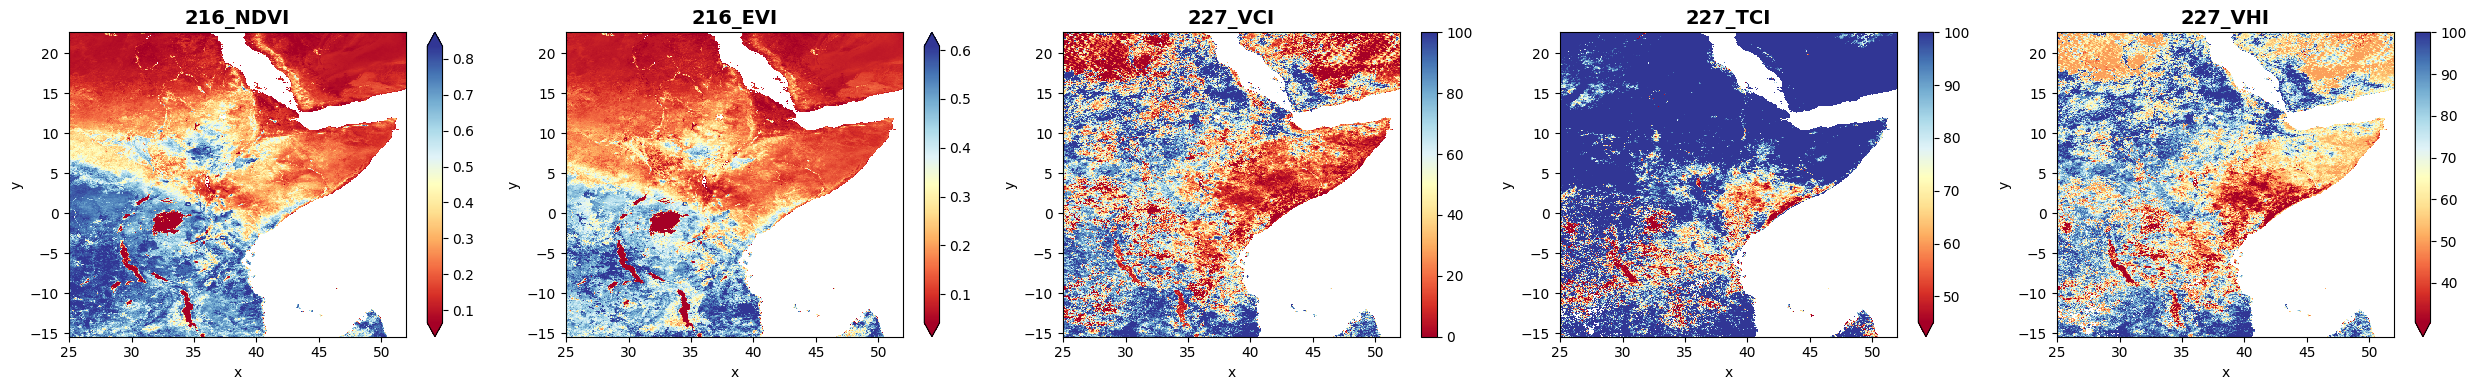

In [11]:
# --- [4] 시각화 검증 ---
with rioxarray.open_rasterio(target_file, masked=True) as da:
    da_masked = da.where(da != -9999)

    fig, axes = plt.subplots(1, 5, figsize=(25, 4))

    da_masked.isel(band=0).plot(ax=axes[0], cmap='RdYlBu', robust=True, cbar_kwargs={'label': ''})
    axes[0].set_title(descriptions[0], fontsize=14, fontweight='bold')

    da_masked.isel(band=1).plot(ax=axes[1], cmap='RdYlBu', robust=True, cbar_kwargs={'label': ''})
    axes[1].set_title(descriptions[1], fontsize=14, fontweight='bold')

    da_masked.isel(band=-3).plot(ax=axes[2], cmap='RdYlBu', robust=True, cbar_kwargs={'label': ''})
    axes[2].set_title(descriptions[-3], fontsize=14, fontweight='bold')

    da_masked.isel(band=-2).plot(ax=axes[3], cmap='RdYlBu', robust=True, cbar_kwargs={'label': ''})
    axes[3].set_title(descriptions[-2], fontsize=14, fontweight='bold')

    da_masked.isel(band=-1).plot(ax=axes[4], cmap='RdYlBu', robust=True, cbar_kwargs={'label': ''})
    axes[4].set_title(descriptions[-1], fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [12]:
# 1. 경로 설정
# 최종 목적지인 공유 폴더(바로가기) 경로 (경로를 정확히 맞춰주세요)
target_dir = '/content/drive/MyDrive/WFP Collab/subnational_price_prediction/data/vegetation/raw'

print(f"🚀 파일 이동을 시작합니다: {source_dir} -> {target_dir}")

# 목적지 폴더가 없다면 생성
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# 2. 파일 찾기 및 이동
# tif 파일들을 찾아서 하나씩 이동
tiff_files = glob.glob(os.path.join(source_dir, f"{EXPORT_DESC}_*.tif"))

if not tiff_files:
    print("⚠️ 이동할 파일이 없습니다. (GEE 다운로드가 완료되었는지 확인하세요)")
else:
    for file_path in tiff_files:
        file_name = os.path.basename(file_path)
        dest_path = os.path.join(target_dir, file_name)

        # 파일 이동 (잘라내기 & 붙여넣기)
        shutil.move(file_path, dest_path)
        print(f"✅ 이동 완료: {file_name}")

    print("\n🎉 모든 파일이 공유 폴더로 성공적으로 이동되었습니다!")

🚀 파일 이동을 시작합니다: /content/drive/MyDrive/GEE_EXPORTS -> /content/drive/MyDrive/WFP Collab/subnational_price_prediction/data/vegetation/raw
✅ 이동 완료: EastAfrica_Vegetation_Indices_2007_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2008_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2009_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2010_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2011_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2012_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2014_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2013_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2015_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2016_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2017_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2019_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2018_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2021_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2020_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_Indices_2024_5km.tif
✅ 이동 완료: EastAfrica_Vegetation_